# BayesNF final model -- ELBO convergence

Downloads the per-step ELBO loss array of the final VI run from S3 and
renders the convergence figure used in Chapter 6 (Section 6.2).

```
s3://thesis-data-ismaktam/bayesnf/runs/vi__final__WY_h1_10__ffrk_full/
    losses.npy
```

Output: `thesis/text/images/06/bnf_final_losses.pdf`.


## 1. Setup


In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import boto3

ROOT = Path('../../..').resolve()
os.chdir(ROOT)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

s3 = boto3.client('s3')
print(f'cwd: {os.getcwd()}')


cwd: /Users/etomengoi/Desktop/precip_interpolation_thesis


## 2. Config


In [2]:
S3_BUCKET = 'thesis-data-ismaktam'
RUN_NAME  = 'vi__final__WY_h1_10__ffrk_full'
S3_PREFIX = f'bayesnf/runs/{RUN_NAME}'

LOCAL_RUN = Path('results/bayesnf/runs') / RUN_NAME
LOCAL_RUN.mkdir(parents=True, exist_ok=True)

OUT_PDF = Path('thesis/text/images/06/bnf_final_losses.pdf')
OUT_PDF.parent.mkdir(parents=True, exist_ok=True)

print(f's3   : s3://{S3_BUCKET}/{S3_PREFIX}/')
print(f'cache: {LOCAL_RUN}')
print(f'out  : {OUT_PDF}')


s3   : s3://thesis-data-ismaktam/bayesnf/runs/vi__final__WY_h1_10__ffrk_full/
cache: results/bayesnf/runs/vi__final__WY_h1_10__ffrk_full
out  : thesis/text/images/06/bnf_final_losses.pdf


## 3. Download artifacts


In [3]:
def _ensure_local(name: str) -> Path:
    local = LOCAL_RUN / name
    if local.exists():
        print(f'  cache hit: {name} ({local.stat().st_size/1e6:.2f} MB)')
        return local
    key = f'{S3_PREFIX}/{name}'
    print(f'  downloading s3://{S3_BUCKET}/{key} ...')
    s3.download_file(S3_BUCKET, key, str(local))
    print(f'  downloaded: {name} ({local.stat().st_size/1e6:.2f} MB)')
    return local

losses_path = _ensure_local('losses.npy')
config_path = _ensure_local('config.json')

cfg = json.loads(config_path.read_text())
N_EPOCHS      = int(cfg['num_epochs'])
ENSEMBLE_SIZE = int(cfg['ensemble_size'])
print(f'num_epochs    : {N_EPOCHS}')
print(f'ensemble_size : {ENSEMBLE_SIZE}')


  cache hit: losses.npy (1.40 MB)
  cache hit: config.json (0.00 MB)
num_epochs    : 100
ensemble_size : 32


## 4. Load and reshape

`losses.npy` has shape `(num_devices, ensemble_per_device, n_steps)`. We
flatten the first two axes so that each row corresponds to one VI member,
and convert step index to fractional epoch.


In [4]:
raw = np.load(losses_path)
print('raw shape:', raw.shape)

losses = raw.reshape(-1, raw.shape[-1])
n_members, n_steps = losses.shape
steps_per_epoch = n_steps / N_EPOCHS
epoch_axis = np.arange(n_steps) / steps_per_epoch

mean_loss = losses.mean(axis=0)

print(f'members        : {n_members}')
print(f'steps          : {n_steps}')
print(f'steps / epoch  : {steps_per_epoch:.1f}')
print(f'first / final  : {mean_loss[0]:.3e} -> {mean_loss[-1]:.3e}')


raw shape: (4, 8, 10900)
members        : 32
steps          : 10900
steps / epoch  : 109.0
first / final  : 5.606e+07 -> 1.199e+07


## 5. Plot

Two panels: linear (left) and symlog (right). Each VI member is drawn as
a faint blue line; the ensemble mean is overlaid in black. No legend, no
title, no plateau annotation.


wrote: thesis/text/images/06/bnf_final_losses.pdf


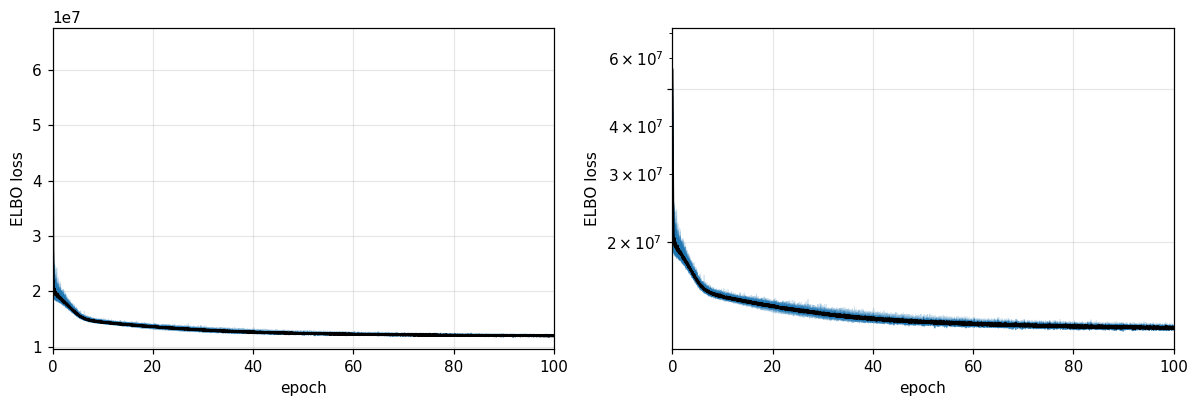

In [5]:
y_min = float(losses.min())
y_max = float(losses.max())
y_pad = 0.04 * (y_max - y_min)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

for ax, use_log in zip(axes, [False, True]):
    for m in range(n_members):
        ax.plot(epoch_axis, losses[m],
                color='tab:blue', alpha=0.18, lw=0.6)
    ax.plot(epoch_axis, mean_loss, color='black', lw=1.4)
    ax.set_xlabel('epoch')
    ax.set_ylabel('ELBO loss')
    ax.set_xlim(0, N_EPOCHS)
    ax.grid(alpha=0.3)
    for spine in ax.spines.values():
        spine.set_visible(True)
    if use_log:
        ax.set_yscale('log')
        ax.set_ylim(y_min * 0.9, y_max * 1.1)
        ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0, 2.0, 5.0)))
        ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs='auto'))
        ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10.0))
    else:
        ax.set_ylim(y_min - y_pad, y_max + y_pad)

plt.tight_layout()
plt.savefig(OUT_PDF, bbox_inches='tight', pad_inches=0.1)
print(f'wrote: {OUT_PDF}')
plt.show()
